# Filtering Down to Candidates with High Similarity

## 1. Setup, Imports & Data Loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

In [ ]:
df = pd.read_csv('/path/to/coconut_with_usrcat.csv')

## 2. Quantify threshold-passing molecules

In [ ]:
# ECFP candidates where ECFP similarity > 0.4
ecfp_candidates = df[df['ecfp_similarity'] > 0.4]
print(ecfp_candidates.shape[0])

# MACCS candidates where MACCS similarity > 0.7
maccs_candidates = df[df['maccs_similarity'] > 0.7]
print(maccs_candidates.shape[0])

# Pharmacophore candidates where Pharmacophore similarity > 0.8
pharmacophore_candidates = df[df['pharmacophore_similarity'] > 0.8]
print(pharmacophore_candidates.shape[0])

# USRCAT candidates are the top 1% of USRCAT similarity scores
usrcat_candidates = df[df['usrcat_similarity'] >= df['usrcat_similarity'].quantile(0.99)]
print(usrcat_candidates.shape[0])

34
4731
6
5927


## 3. Save high-similarity candidates for virtual screening

In [ ]:
high_similarity_candidates = df[
    (df['ecfp_similarity'] > 0.4) |
    (df['maccs_similarity'] > 0.7) |
    (df['pharmacophore_similarity'] > 0.8) |
    (df['usrcat_similarity'] >= df['usrcat_similarity'].quantile(0.99))
]
print("Number of high similarity candidates:", high_similarity_candidates.shape[0])

# remove any candidates with 'acarbose' in the 'name' column (case insensitive)
high_similarity_candidates = high_similarity_candidates[~high_similarity_candidates['name'].str.contains('acarbose', case=False, na=False)]
print("Number of high similarity candidates after removing acarbose:", high_similarity_candidates.shape[0])

high_similarity_candidates.to_csv('high_similarity_candidates.csv', index=False)

Number of high similarity candidates: 10353
Number of high similarity candidates after removing acarbose: 10340


In [50]:
# let's look at the most similar candidates for each fingerprint type
high_similarity_candidates.sort_values(by='usrcat_similarity', ascending=False).head(50)

,identifier,canonical_smiles,standard_inchi,standard_inchi_key,name,iupac_name,annotation_level,total_atom_count,heavy_atom_count,molecular_weight,...,sanitized_smiles,normalized_smiles,ecfp,pharmacophore_fp,maccs_fp,ecfp_similarity,pharmacophore_similarity,maccs_similarity,usrcat_fp,usrcat_similarity
599662,CNP0331673.3,OCC1=C[C@@H](N[C@@H]2C[C@@H](CO)[C@H](O[C@H]3O...,InChI=1S/C26H45NO18/c28-3-7-1-9(14(32)18(36)13...,FSQHOQRBXQDUST-UBMQKTDRSA-N,NaN,"(2~{R},3~{R},4~{S},5~{R},6~{S})-2-[[(2~{R},3~{...",1,90,45,659.64,...,OCC1=C[C@@H](N[C@@H]2C[C@@H](CO)[C@H](O[C@H]3O...,OCC1=C[C@@H](N[C@@H]2C[C@@H](CO)[C@H](O[C@H]3O...,0100000000000000000000000000000000000010000000...,1011000000000000000100000000000000000000000000...,0000000000000000000000000000000000000000000000...,0.167539,0.283582,0.934783,"[5.642037771597408, 2.547201278784658, 0.36929...",0.436974
375690,CNP0226609.8,C[C@H]1O[C@@H](O[C@H]2[C@@H](O)[C@H](O)[C@H](O...,InChI=1S/C25H43NO18/c1-6-11(26-8-2-7(3-27)12(3...,XUFXOAAUWZOOIT-MJMUWAIISA-N,NaN,"(2~{S},3~{R},4~{S},5~{R},6~{S})-5-[(2~{S},3~{S...",1,87,44,645.61,...,C[C@H]1O[C@@H](O[C@H]2[C@@H](O)[C@H](O)[C@H](O...,C[C@H]1O[C@@H](O[C@H]2[C@@H](O)[C@H](O)[C@H](O...,0000000000010000000000000000000000000000000000...,1011000000000000000100000000000000000000000000...,0000000000000000000000000000000000000000000000...,0.200000,0.687500,0.955556,"[5.797190781040351, 2.6145256660423994, 0.3053...",0.410363
710918,CNP0256795.1,O=C[C@H](O)[C@@H](O)[C@H](O[C@H]1O[C@H](CO)[C@...,InChI=1S/C25H43NO19/c27-2-7-1-8(15(35)18(38)14...,SWCIZDWVIVXZIC-GCMZRJIBSA-N,NaN,"(2~{R},3~{R},4~{R},5~{R})-4-[(2~{R},3~{R},4~{R...",4,88,45,661.61,...,O=C[C@H](O)[C@@H](O)[C@H](O[C@H]1O[C@H](CO)[C@...,O=C[C@H](O)[C@@H](O)[C@H](O[C@H]1O[C@H](CO)[C@...,0000000000001000000000000000000000000000000000...,1011000000000000000100000000000000000000000000...,0000000000000000000000000000000000000000000000...,0.613139,0.811111,0.977778,"[5.63000898518682, 2.452398283057256, -0.42910...",0.388345
368970,CNP0256795.2,O=C[C@H](O)[C@H](O)[C@H](O[C@H]1O[C@H](CO)[C@@...,InChI=1S/C25H43NO19/c27-2-7-1-8(15(35)18(38)14...,SWCIZDWVIVXZIC-ZCVIYBMNSA-N,NaN,"(2~{R},3~{S},4~{R},5~{R})-4-[(2~{R},3~{R},4~{R...",4,88,45,661.61,...,O=C[C@H](O)[C@H](O)[C@H](O[C@H]1O[C@H](CO)[C@@...,O=C[C@H](O)[C@H](O)[C@H](O[C@H]1O[C@H](CO)[C@@...,0000000000001000000000000000000000000000000000...,1011000000000000000100000000000000000000000000...,0000000000000000000000000000000000000000000000...,0.631579,0.811111,0.977778,"[5.554610784419617, 2.4402266253529303, -0.324...",0.384334
88389,CNP0535979.1,NCCCC(N)CC(=O)NCCCC(N)CC(=O)NC1C(NC2=N[C@@H]3[...,InChI=1S/C25H46N10O9/c26-5-1-3-11(27)7-15(37)3...,TWWOHQBJOSKKBN-NDNYBURPSA-N,Lavendothricin E,"[6-[[(3~{a}~{S},7~{R},7~{a}~{S})-4,7-dihydroxy...",3,90,44,630.70,...,NCCCC(N)CC(=O)NCCCC(N)CC(=O)NC1C(NC2=N[C@@H]3[...,NCCCC(N)CC(=O)NCCCC(N)CC(=O)NC1C(NC2=N[C@@H]3[...,0000000000000000000000000000000010000000010000...,1111000000000000010101000000000000000000000000...,0000000000000000000000010100000000000000000100...,0.066372,0.085714,0.577465,"[6.262496096047415, 2.507544570862034, -0.5298...",0.365255
344499,CNP0265266.3,OCC1=C[C@@H](N[C@@H]2C[C@@H](CO)[C@H](O[C@H]3O...,InChI=1S/C26H45NO18/c28-3-7-1-9(14(33)17(36)13...,MSZAIRLAOKNKFW-MMXHAXQZSA-N,NaN,"(2~{S},3~{S},4~{R},5~{R},6~{R})-2-[(2~{R},3~{R...",1,90,45,659.64,...,OCC1=C[C@@H](N[C@@H]2C[C@@H](CO)[C@H](O[C@H]3O...,OCC1=C[C@@H](N[C@@H]2C[C@@H](CO)[C@H](O[C@H]3O...,0100000000000000000000000000000000000010000000...,1011000000000000100100000000000000000000000000...,0000000000000000000000000000000000000000000000...,0.157609,0.435897,0.934783,"[5.300096357429121, 2.3169929135579386, 0.4279...",0.364169
249847,CNP0333707.3,C[C@H]1O[C@@H](O)[C@@H](O)[C@@H](O)[C@@H]1O[C@...,InChI=1S/C24H42O18/c1-6-20(15(31)17(33)22(36)3...,CNGQRRMZWAKWFW-BBFRRCSPSA-N,NaN,"(2~{R},3~{S},4~{R},5~{S},6~{R})-5-[(1~{R},2~{S...",1,84,42,618.58,...,C[C@H]1O[C@@H](O)[C@@H](O)[C@@H](O)[C@@H]1O[C@...,C[C@H]1O[C@@H](O)[C@@H](O)[C@@H](O)[C@@H]1O[C@

In [52]:
high_similarity_candidates['chemical_super_class'].value_counts()

chemical_super_class
Lipids and lipid-like molecules              5070
Organic oxygen compounds                     2574
Organic acids and derivatives                 965
Organoheterocyclic compounds                  611
Phenylpropanoids and polyketides              237
Benzenoids                                    123
Organic Polymers                              120
Alkaloids and derivatives                      30
Organic nitrogen compounds                     18
Lignans, neolignans and related compounds       2
Name: count, dtype: int64

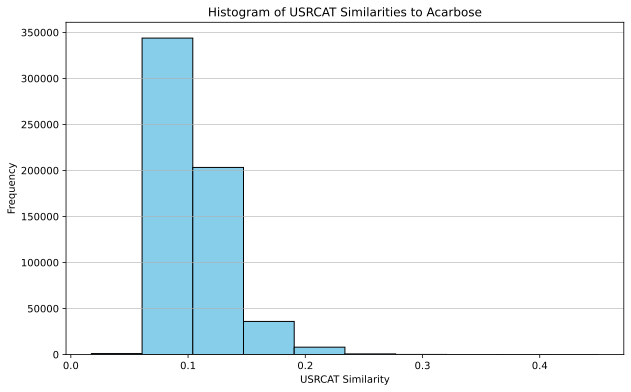

In [ ]:
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# histogram of similarities
plt.figure(figsize=(10, 6))
plt.hist(df['usrcat_similarity'].dropna(), color='skyblue', edgecolor='black')
plt.title('Histogram of USRCAT Similarities to Acarbose')
plt.xlabel('USRCAT Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()